# Notebook 2 — Single Name CDS Pricer

End-to-end pricing of a single CDS trade:

1. Build curves from market data
2. Generate payment schedule
3. Price premium and protection legs
4. Solve for par spread and upfront payment
5. Produce a full pricing summary

**Example trade:** Vodafone 5Y protection buyer, £10mm notional, 100bps standard coupon

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

from cds.curves import DiscountCurve, SurvivalCurve
from cds.schedule import build_schedule
from cds.pricer import (
    risky_annuity, premium_leg, protection_leg,
    par_spread, upfront, npv
)

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'font.size':         11,
})

BLUE = '#2563EB'
RED  = '#DC2626'
GREY = '#6B7280'

print('Ready.')

Ready.


In [2]:
# ── Load market data and define trade ────────────────────────
with open('../data/dummy/market_data.json') as f:
    mkt = json.load(f)

swap_rates = {float(k): v for k, v in mkt['swap_curve'].items()
              if k != 'comment'}

spread_curve = {
    float(k): v
    for k, v in mkt['spread_curves']['VOD'].items()
    if k not in ('name', 'rating', 'sector', 'recovery', 'comment')
}

# Trade parameters
TRADE_DATE  = date(2026, 6, 13)
MATURITY    = date(2031, 6, 20)
NOTIONAL    = 10_000_000
COUPON_BPS  = 100          # IG standard
RECOVERY    = 0.40
POSITION    = 1            # protection buyer

# Build curves and schedule
dc       = DiscountCurve(swap_rates)
sc       = SurvivalCurve(spread_curve, dc, recovery=RECOVERY, trade_date=TRADE_DATE)
schedule = build_schedule(TRADE_DATE, MATURITY)

print(f'Trade:      Vodafone 5Y CDS')
print(f'Trade date: {TRADE_DATE}')
print(f'Maturity:   {MATURITY}')
print(f'Notional:   £{NOTIONAL:,.0f}')
print(f'Coupon:     {COUPON_BPS}bps')
print(f'Periods:    {len(schedule)}')

Trade:      Vodafone 5Y CDS
Trade date: 2026-06-13
Maturity:   2031-06-20
Notional:   £10,000,000
Coupon:     100bps
Periods:    21


---
## 1. Payment Schedule

The CDS makes quarterly coupon payments on IMM dates (Mar/Jun/Sep/Dec 20th).
The first period is a short stub from trade date to the next IMM date.

In [3]:
print(f'{"#":>3}  {"Period Start":>14}  {"Period End":>12}  {"DCF":>8}  '
      f'{"Year Frac":>10}  {"Survival":>10}  {"DF":>8}')
print('-' * 72)

for i, (t_start, t_end, dcf, yf) in enumerate(schedule, 1):
    sp = sc.survival_prob(yf)
    df = dc.discount_factor(yf)
    print(f'{i:>3}  {str(t_start):>14}  {str(t_end):>12}  '
          f'{dcf:>8.4f}  {yf:>10.4f}  {sp:>10.4f}  {df:>8.4f}')

  #    Period Start    Period End       DCF   Year Frac    Survival        DF
------------------------------------------------------------------------
  1      2026-06-13    2026-06-20    0.0194      0.0192      0.9999    0.9992
  2      2026-06-20    2026-09-20    0.2556      0.2712      0.9979    0.9884
  3      2026-09-20    2026-12-20    0.2528      0.5205      0.9961    0.9778
  4      2026-12-20    2027-03-20    0.2500      0.7671      0.9942    0.9674
  5      2027-03-20    2027-06-20    0.2556      1.0192      0.9922    0.9570
  6      2027-06-20    2027-09-20    0.2556      1.2712      0.9886    0.9470
  7      2027-09-20    2027-12-20    0.2528      1.5205      0.9850    0.9375
  8      2027-12-20    2028-03-20    0.2528      1.7699      0.9815    0.9282
  9      2028-03-20    2028-06-20    0.2556      2.0219      0.9777    0.9190
 10      2028-06-20    2028-09-20    0.2556      2.2740      0.9717    0.9103
 11      2028-09-20    2028-12-20    0.2528      2.5233      0.9659  

---
## 2. Leg Pricing

**Premium leg:** survival-weighted PV of fixed coupon payments

$$PV_{\text{prem}} = C \sum_i S(t_i) \cdot DF(t_i) \cdot \Delta t_i$$

**Protection leg:** expected PV of default payment

$$PV_{\text{prot}} = (1-R) \sum_i [S(t_{i-1}) - S(t_i)] \cdot DF(t_i)$$

In [4]:
ra  = risky_annuity(schedule, sc, dc)
pl  = premium_leg(schedule, sc, dc, COUPON_BPS)
ptl = protection_leg(schedule, sc, dc, RECOVERY)
ps  = par_spread(schedule, sc, dc, RECOVERY)
uf  = upfront(schedule, sc, dc, COUPON_BPS, NOTIONAL, RECOVERY, POSITION)

print('=' * 48)
print(f'  PRICING SUMMARY — Vodafone 5Y CDS')
print('=' * 48)
print(f'  Risky Annuity:     {ra:.4f} years')
print(f'  Premium Leg PV:    {pl:.4f} per unit notional')
print(f'  Protection Leg PV: {ptl:.4f} per unit notional')
print(f'  Par Spread:        {ps:.2f} bps')
print(f'  Contract Coupon:   {COUPON_BPS:.2f} bps')
print(f'  Spread Diff:       {ps - COUPON_BPS:.2f} bps')
print(f'  Upfront Payment:   £{uf:,.0f}')
print(f'  (buyer pays)' if uf > 0 else f'  (seller pays)')
print('=' * 48)

  PRICING SUMMARY — Vodafone 5Y CDS
  Risky Annuity:     4.4034 years
  Premium Leg PV:    0.0440 per unit notional
  Protection Leg PV: 0.0529 per unit notional
  Par Spread:        120.19 bps
  Contract Coupon:   100.00 bps
  Spread Diff:       20.19 bps
  Upfront Payment:   £88,909
  (buyer pays)


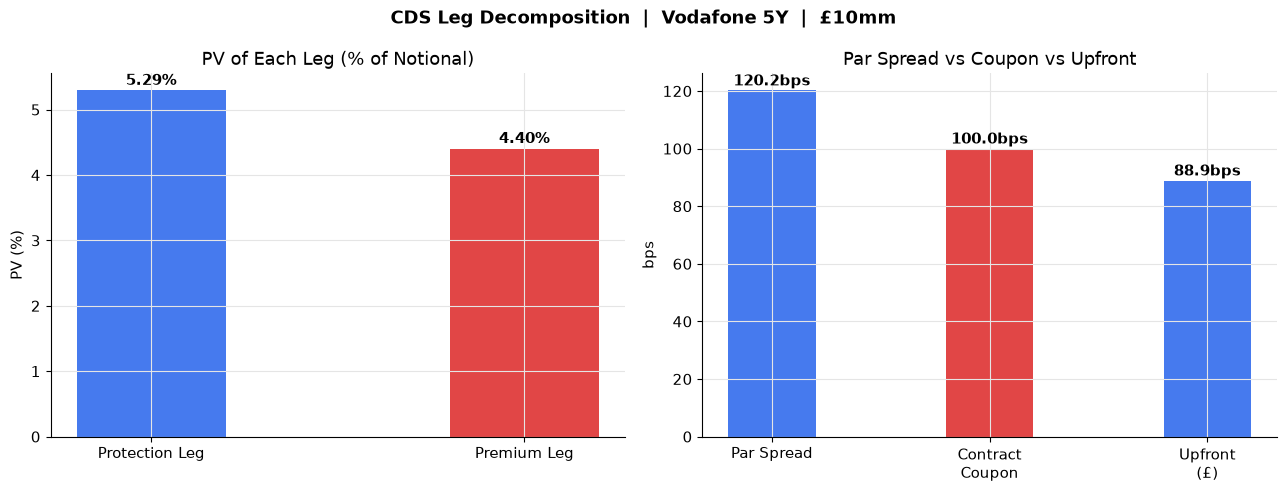

In [5]:
# ── Visualise leg decomposition ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CDS Leg Decomposition  |  Vodafone 5Y  |  £10mm', 
             fontsize=13, fontweight='bold')

# Left: bar chart of legs
ax = axes[0]
bars = ax.bar(
    ['Protection Leg', 'Premium Leg'],
    [ptl * 100, pl * 100],
    color=[BLUE, RED],
    alpha=0.85,
    width=0.4
)
ax.set_title('PV of Each Leg (% of Notional)')
ax.set_ylabel('PV (%)')
for bar, val in zip(bars, [ptl * 100, pl * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Right: upfront waterfall
ax = axes[1]
categories = ['Par Spread', 'Contract\nCoupon', 'Upfront\n(£)']
values     = [ps, COUPON_BPS, uf / NOTIONAL * 10_000]  # all in bps equiv
colours    = [BLUE, RED, BLUE if uf > 0 else RED]

bars = ax.bar(categories, values, color=colours, alpha=0.85, width=0.4)
ax.set_title('Par Spread vs Coupon vs Upfront')
ax.set_ylabel('bps')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}bps', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02a_leg_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Multi-Entity Comparison

Price all trades from `trades.json` and compare key metrics side by side.

In [6]:
with open('../data/dummy/trades.json') as f:
    trade_data = json.load(f)['trades']

results = []

for trade in trade_data:
    entity = trade['entity']
    sc_data = {
        float(k): v
        for k, v in mkt['spread_curves'][entity].items()
        if k not in ('name', 'rating', 'sector', 'recovery', 'comment')
    }

    t_date = date.fromisoformat(trade['trade_date'])
    t_mat  = date.fromisoformat(trade['maturity'])
    rec    = trade['recovery_rate']
    pos    = 1 if trade['position'] == 'protection_buyer' else -1

    dc_t  = DiscountCurve(swap_rates)
    sc_t  = SurvivalCurve(sc_data, dc_t, recovery=rec, trade_date=t_date)
    sch_t = build_schedule(t_date, t_mat)

    ps_t  = par_spread(sch_t, sc_t, dc_t, rec)
    uf_t  = upfront(sch_t, sc_t, dc_t,
                    trade['coupon_bps'], trade['notional'], rec, pos)
    ra_t  = risky_annuity(sch_t, sc_t, dc_t)

    results.append({
        'ID':            trade['id'],
        'Name':          trade['name'],
        'Notional':      trade['notional'],
        'Coupon':        trade['coupon_bps'],
        'Par Spread':    round(ps_t, 1),
        'Risky Ann':     round(ra_t, 3),
        'Upfront (£)':   round(uf_t, 0),
        'Position':      trade['position'],
    })

print(f'{"ID":>6}  {"Name":<28}  {"Coupon":>8}  {"Par Spd":>9}  '
      f'{"Risky Ann":>10}  {"Upfront":>12}')
print('-' * 85)
for r in results:
    print(f'{r["ID"]:>6}  {r["Name"]:<28}  '
          f'{r["Coupon"]:>6}bps  {r["Par Spread"]:>7.1f}bps  '
          f'{r["Risky Ann"]:>10.3f}  £{r["Upfront (£)"]:>10,.0f}')

    ID  Name                            Coupon    Par Spd   Risky Ann       Upfront
-------------------------------------------------------------------------------------
TRD001  Vodafone 5Y IG                   100bps    120.2bps       4.403  £    88,909
TRD002  iTraxx XOVER 5Y                  500bps    310.2bps       4.088  £  -775,991
TRD003  Tesla 5Y HY                      500bps    290.1bps       4.143  £  -434,827
TRD004  Vodafone 3Y short dated          100bps     90.2bps       2.810  £    27,562
TRD005  Distressed Entity 5Y             500bps   1502.1bps       3.051  £   611,521
